# Phase 3 — Classical Classification

**Goal:** Train multiple scikit-learn classifiers to predict a star's Spectral Class from its physical properties. Compare their performance.

**Libraries:** `pandas`, `scikit-learn`

**Input:** `../star_dataset_clean.csv`

**Models:** K-Nearest Neighbors, Logistic Regression, Decision Tree

In [16]:
# --- Imports ---
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [17]:
# --- Load & Prepare Data ---
# Load star_dataset_clean.csv
#
# Define features (X) and target (y):
#   Features: 'Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)'
#   Target:   'Spectral Class'
#
# Encode the target string labels to integers using LabelEncoder
#   - fit_transform the target column
#   - Save the encoder so you can decode predictions back to class names later
#
# Split into train and test sets using train_test_split
#   - Use test_size=0.2 and random_state=42 for reproducibility
#
# Scale features using StandardScaler
#   - fit on training data only, then transform both train and test
#   - This prevents data leakage from the test set

df = pd.read_csv("../star_dataset_clean.csv")
df.info()

X = df[['Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)']]
y = df['Spectral Class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y_encoded,
  test_size=0.2,
  random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Classes:", label_encoder.classes_)

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               29 non-null     str    
 1   Distance (ly)      29 non-null     float64
 2   Luminosity (L/Lo)  29 non-null     float64
 3   Radius (R/Ro)      29 non-null     float64
 4   Temperature (K)    29 non-null     float64
 5   Spectral Class     29 non-null     str    
dtypes: float64(4), str(2)
memory usage: 1.5 KB
Training shape: (23, 4)
Test shape: (6, 4)
Classes: ['A0V' 'A1V' 'A2Ia' 'A3V' 'A7V' 'A9II' 'B0.5IV' 'B0Ia' 'B1III' 'B1III-IV'
 'B2III' 'B6Vep' 'B7V' 'B8Ia' 'F5IV-V' 'F7Ib' 'G2V' 'G8III' 'K1.5III'
 'K1V' 'K5III' 'M1.5Iab' 'M2.1V' 'M2Iab' 'M3.5V' 'M4Ve' 'M6V' 'M7IIIe']


K=1, CV Accuracy: 0.0893
K=3, CV Accuracy: 0.0893
K=5, CV Accuracy: 0.0893
K=7, CV Accuracy: 0.0893
K=9, CV Accuracy: 0.0893
KNN Classification Report:
              precision    recall  f1-score   support

         A0V       0.00      0.00      0.00       1.0
         A1V       0.00      0.00      0.00       0.0
       B1III       0.00      0.00      0.00       1.0
       B2III       0.00      0.00      0.00       1.0
        B8Ia       0.00      0.00      0.00       1.0
         G2V       0.00      0.00      0.00       0.0
       G8III       0.00      0.00      0.00       1.0
     K1.5III       0.00      0.00      0.00       0.0
        M4Ve       0.00      0.00      0.00       1.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavio

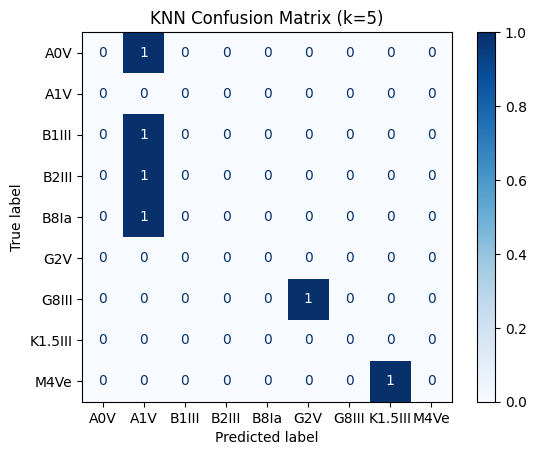

In [18]:
# --- Model 1: K-Nearest Neighbors (KNN) ---
# Use KFold instead of the default StratifiedKFold — with only 23 training samples
# spread across many classes, some classes have just 1 sample which breaks stratification.
kf = KFold(n_splits=3, shuffle=True, random_state=42)

k_values = [1, 3, 5, 7, 9]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=kf)
    print(f"K={k}, CV Accuracy: {cv_scores.mean():.4f}")

best_k = 5
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

present_labels = sorted(set(y_test) | set(y_pred_knn))
present_names = label_encoder.inverse_transform(present_labels)

print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, labels=present_labels, target_names=present_names))
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=present_labels)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=present_names)
disp_knn.plot(cmap=plt.cm.Blues)
plt.title(f"KNN Confusion Matrix (k={best_k})")
plt.show()

c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1469: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         A0V       0.00      0.00      0.00       1.0
         A1V       0.00      0.00      0.00       0.0
        A2Ia       0.00      0.00      0.00       0.0
      B0.5IV       0.00      0.00      0.00       0.0
       B1III       0.00      0.00      0.00       1.0
       B2III       0.00      0.00      0.00       1.0
        B8Ia       0.00      0.00      0.00       1.0
       G8III       0.00      0.00      0.00       1.0
        M4Ve       0.00      0.00      0.00       1.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



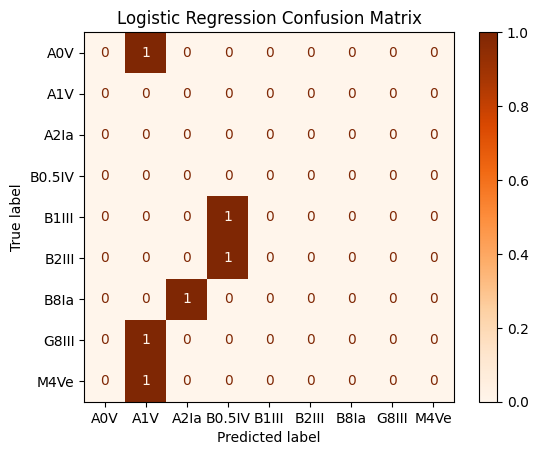

In [19]:
# --- Model 2: Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_logreg = log_reg.predict(X_test_scaled)

present_labels = sorted(set(y_test) | set(y_pred_logreg))
present_names = label_encoder.inverse_transform(present_labels)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg, labels=present_labels, target_names=present_names))
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=present_labels)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=present_names)
disp_logreg.plot(cmap=plt.cm.Oranges)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\tree\_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

Decision Tree Classification Report:
              precision    recall  f1-score   support

         A0V       0.00      0.00      0.00       1.0
         A1V       0.00      0.00      0.00       0.0
        A2Ia       0.00      0.00      0.00       0.0
      B0.5IV       0.00      0.00      0.00       0.0
       B1III       0.00      0.00      0.00       1.0
       B2III       0.00      0.00      0.00       1.0
       B6Vep       0.00      0.00      0.00       0.0
        B8Ia       0.00      0.00      0.00       1.0
       G8III       0.00      0.00      0.00       1.0
         K1V       0.00      0.00      0.00       0.0
        M4Ve       0.00      0.00      0.00       1.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



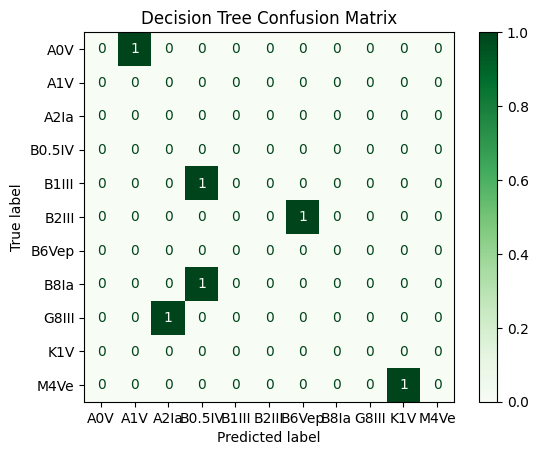

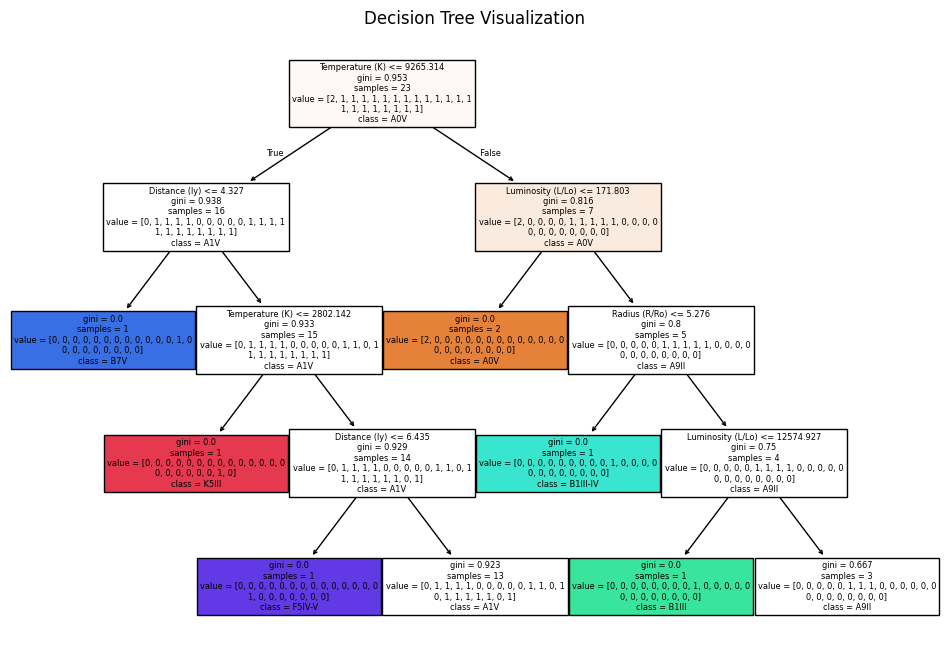

In [20]:
# --- Model 3: Decision Tree ---
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

present_labels = sorted(set(y_test) | set(y_pred_tree))
present_names = label_encoder.inverse_transform(present_labels)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree, labels=present_labels, target_names=present_names))
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=present_labels)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=present_names)
disp_tree.plot(cmap=plt.cm.Greens)
plt.title("Decision Tree Confusion Matrix")
plt.show()

plt.figure(figsize=(12, 8))
plot_tree(tree_clf, feature_names=X.columns, class_names=label_encoder.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

                 Model  Test Accuracy
0                  KNN            0.0
1  Logistic Regression            0.0
2        Decision Tree            0.0


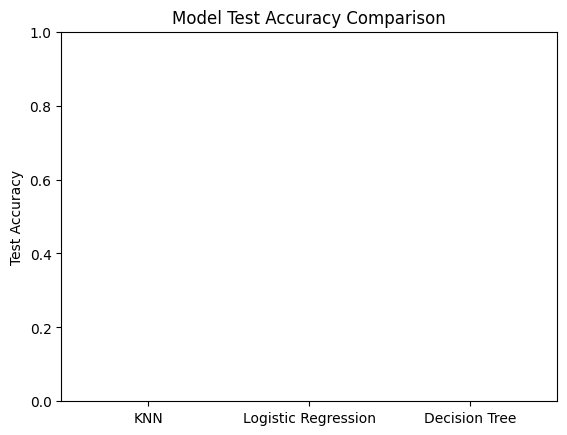

In [21]:
# --- Model Comparison ---
model_accuracies = {
    "KNN": (y_test == y_pred_knn).mean(),
    "Logistic Regression": (y_test == y_pred_logreg).mean(),
    "Decision Tree": (y_test == y_pred_tree).mean()
}
accuracy_df = pd.DataFrame(list(model_accuracies.items()), columns=["Model", "Test Accuracy"])
print(accuracy_df)
plt.bar(accuracy_df["Model"], accuracy_df["Test Accuracy"], color=['blue', 'orange', 'green'])
plt.ylabel("Test Accuracy")
plt.title("Model Test Accuracy Comparison")
plt.ylim(0, 1)
plt.show()